# Comprehensive SEIXHRD Model Experiments
**Date:** November 29, 2025
**Model Version:** 2.0 (Three-Factor Vaccine, Split-X, Demographics)

This notebook contains a comprehensive suite of 15 experiments designed to validate the mathematical integrity of the model and explore complex epidemiological dynamics.

## Table of Contents

### I. Mathematical Validation
1. **Population Conservation**: Verifying $\sum N = \text{const}$ (or accounting for demographics)
2. **Death Monotonicity**: Ensuring cumulative deaths never decrease
3. **Split-X Consistency**: Verifying $D_{treated} + D_{untreated} \approx D_{total}$

### II. Three-Factor Vaccine Analysis
4. **VE Component Decomposition**: Analyzing impact of $VE_{inf}$ vs $VE_{sev}$ vs $VE_{death}$
5. **Vaccine Profile Comparison**: Comparing all 7 predefined vaccine profiles
6. **Waning Dynamics**: Impact of waning destination ($S$ vs $S_{vax}$) and rates

### III. Healthcare Capacity Dynamics
7. **Hill Coefficient Sensitivity**: Effect of gating function steepness
8. **Optimal Ward:ICU Ratio**: Resource allocation analysis
9. **Healthcare System Comparison**: Stress testing across 9 system configurations

### IV. Time-Varying Dynamics
10. **Seasonality $\times$ Waning**: Interaction of seasonal forcing and immunity loss
11. **Intervention Strategy Comparison**: Evaluating 12 intervention presets
12. **Adaptive Policy**: Trigger-based intervention switching

### V. Demographics & Long-Term
13. **Demographic Dynamics**: Multi-year simulations with births/deaths
14. **Endemic Equilibrium**: Long-term stability analysis

### VI. Sensitivity & Synthesis
15. **Multi-Parameter Heatmaps**: Interaction effects of $\beta$, Capacity, and VE

In [1]:
import sys
import os
import warnings

# Add project root to path
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from copy import deepcopy

# Model Imports
from master_hospital_model import simulate_master_hospital_model
from config_helpers import (
    get_scenario_params, compare_vaccine_profiles,
    compare_healthcare_systems, create_sensitivity_variants,
    get_vaccine_profile, list_vaccine_profiles, get_healthcare_systems,
    list_scenarios, get_vaccination_strategies
)
from config import (
    SCENARIO_REGISTRY, AGE_PARAMS_EMPIRICAL, CONTACT_MATRIX_DEFAULT,
    INTERVENTION_EARLY_STRONG, INTERVENTION_CYCLICAL,
    VACCINE_PROFILES, HEALTHCARE_SYSTEM_URBAN
)

# Plotting Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
COLORS = sns.color_palette("deep")

In [2]:
def plot_experiment_results(results_dict, title, metric='H_ward_total', ylabel='Ward Occupancy'):
    """Generic helper to plot a metric across multiple scenarios."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for name, res in results_dict.items():
        ax.plot(res['times'], res[metric], label=name, linewidth=2)
        
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Days')
    ax.set_ylabel(ylabel)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax

def check_conservation(results, initial_pop, tolerance=1e-5):
    """Verify population conservation."""
    # Sum of all compartments
    total_pop = np.zeros_like(results['times'])
    
    # Add all tracked compartments
    # Note: We need to sum all compartment arrays. 
    # The results dict contains lists of arrays for each compartment (one per age group)
    # We need to sum across age groups and then across compartments
    
    compartment_names = [
        'S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D',
        'S_vax', 'E_vax', 'I_vax', 'X_queued_vax', 'X_admitted_vax', 
        'H_ward_vax', 'H_icu_vax', 'R_vax', 'D_vax'
    ]
    
    for name in compartment_names:
        if name in results:
            # results[name] is a list of arrays (one per age group)
            # Sum across age groups
            comp_total = np.sum(results[name], axis=0)
            total_pop += comp_total
             
    # Check deviation
    deviation = np.abs(total_pop - initial_pop)
    max_dev = np.max(deviation)
    passed = max_dev < tolerance
    return passed, max_dev, total_pop

# I. Mathematical Validation

These experiments verify the fundamental mathematical properties of the model. Any failure here indicates a bug in the ODE equations or solver configuration.

Running Experiment 1: Population Conservation...
Case A (Closed): PASSED
  Max deviation: 4.66e-10 (Tolerance: 1e-5)
Case B (Open):   PASSED
  Max deviation: 5.24e-10


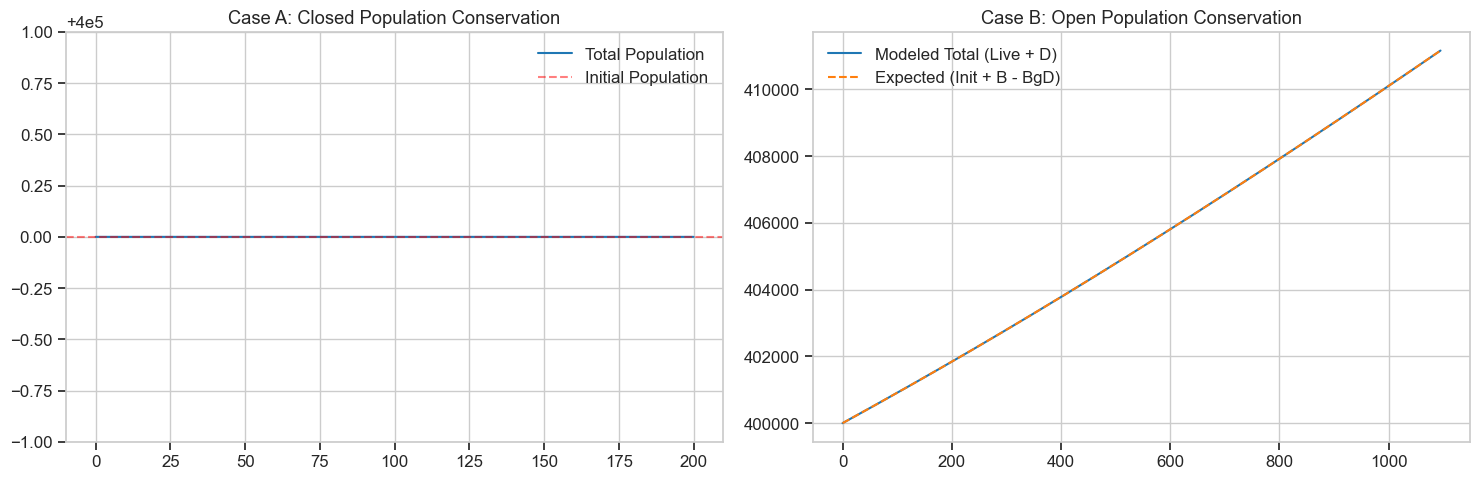

In [3]:
# Experiment 1: Population Conservation

print("Running Experiment 1: Population Conservation...")

# Case A: Closed Population (No Demographics)
params_closed = get_scenario_params('baseline')
params_closed['demographic_config'] = None # Ensure no demographics
results_closed = simulate_master_hospital_model(**params_closed)

initial_pop = sum(params_closed['age_pops'])
passed_closed, max_dev_closed, total_pop_closed = check_conservation(results_closed, initial_pop)

print(f"Case A (Closed): {'PASSED' if passed_closed else 'FAILED'}")
print(f"  Max deviation: {max_dev_closed:.2e} (Tolerance: 1e-5)")

# Case B: Open Population (With Demographics)
params_open = get_scenario_params('population_dynamics')
results_open = simulate_master_hospital_model(**params_open)

# For open population: Total(t) = Live(t) + D(t) = Initial + Births(t) - BackgroundDeaths(t)
# Wait, D(t) are disease deaths. Background deaths are removed from the system.
# So: Live(t) + D(t) + BackgroundDeaths(t) = Initial + Births(t)
# Let's verify: Sum(All Compartments) = Initial + CumBirths - CumBackgroundDeaths

# Calculate total population in all compartments (Live + Disease Deaths)
total_compartments_open = np.zeros_like(results_open['times'])
compartment_names = [
    'S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D',
    'S_vax', 'E_vax', 'I_vax', 'X_queued_vax', 'X_admitted_vax', 
    'H_ward_vax', 'H_icu_vax', 'R_vax', 'D_vax'
]
for name in compartment_names:
    if name in results_open:
        total_compartments_open += np.sum(results_open[name], axis=0)

# Expected total = Initial + Births - Background Deaths
# Note: cum_births and cum_background_deaths are tracked variables (summed across ages)
expected_total = initial_pop + np.sum(results_open['cum_births'], axis=0) - np.sum(results_open['cum_background_deaths'], axis=0)

deviation_open = np.abs(total_compartments_open - expected_total)
max_dev_open = np.max(deviation_open)
passed_open = max_dev_open < 1e-5

print(f"Case B (Open):   {'PASSED' if passed_open else 'FAILED'}")
print(f"  Max deviation: {max_dev_open:.2e}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(results_closed['times'], total_pop_closed, label='Total Population')
ax1.axhline(initial_pop, color='r', linestyle='--', alpha=0.5, label='Initial Population')
ax1.set_title('Case A: Closed Population Conservation')
ax1.set_ylim(initial_pop - 1, initial_pop + 1)
ax1.legend()

ax2.plot(results_open['times'], total_compartments_open, label='Modeled Total (Live + D)')
ax2.plot(results_open['times'], expected_total, '--', label='Expected (Init + B - BgD)')
ax2.set_title('Case B: Open Population Conservation')
ax2.legend()
plt.savefig('../results/population_conservation_visual_regression_test.png')
plt.tight_layout()
plt.show()

In [4]:
# Experiment 2: Death Monotonicity

print("Running Experiment 2: Death Monotonicity...")
failures = []

# Test a subset of diverse scenarios to save time
test_scenarios = ['baseline', 'covid_delta', 'resource_limited', 'stress_test']

for name in test_scenarios:
    params = get_scenario_params(name)
    res = simulate_master_hospital_model(**params)
    
    # Check if D_total is monotonically increasing
    d_total = res['D_total']
    # Allow tiny numerical noise (negative diffs > -1e-9 are ignored)
    diffs = np.diff(d_total)
    min_diff = np.min(diffs)
    is_monotonic = min_diff >= -1e-9
    
    if not is_monotonic:
        failures.append(name)
        print(f"  {name}: FAILED (Min diff: {min_diff:.2e})")
    else:
        print(f"  {name}: PASSED")

if not failures:
    print("All tested scenarios passed monotonicity check.")

Running Experiment 2: Death Monotonicity...
  baseline: PASSED
  covid_delta: PASSED
  resource_limited: PASSED
  stress_test: PASSED
All tested scenarios passed monotonicity check.


Running Experiment 3: Split-X Consistency...
Split-X Consistency: PASSED
  Max deviation: 3.64e-11


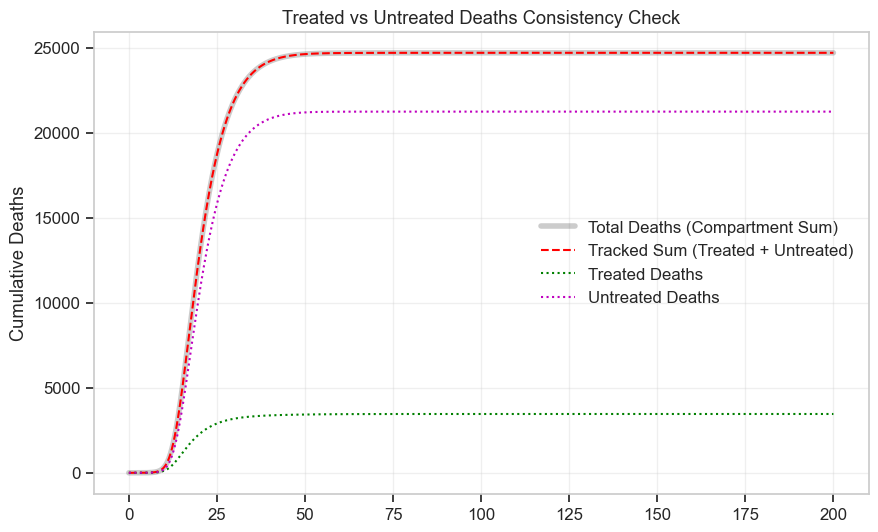

In [5]:
# Experiment 3: Split-X Consistency

print("Running Experiment 3: Split-X Consistency...")

# Use a scenario with high capacity stress to generate untreated deaths
params = get_scenario_params('stress_test')
res = simulate_master_hospital_model(**params)

# Sum treated and untreated deaths (summing across age groups)
d_treated = np.sum(res['D_treated'], axis=0)
d_untreated = np.sum(res['D_untreated'], axis=0)
d_total_tracked = d_treated + d_untreated

# Also check vaccinated deaths if they exist
if 'D_vax_treated' in res:
    d_vax_treated = np.sum(res['D_vax_treated'], axis=0)
    d_vax_untreated = np.sum(res['D_vax_untreated'], axis=0)
    d_total_tracked += d_vax_treated + d_vax_untreated

# Compare with main D compartment (D + D_vax)
d_main = res['D_total']

# Calculate deviation
deviation = np.abs(d_main - d_total_tracked)
max_dev = np.max(deviation)
passed = max_dev < 1e-5

print(f"Split-X Consistency: {'PASSED' if passed else 'FAILED'}")
print(f"  Max deviation: {max_dev:.2e}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(res['times'], d_main, 'k-', linewidth=4, alpha=0.2, label='Total Deaths (Compartment Sum)')
ax.plot(res['times'], d_total_tracked, 'r--', label='Tracked Sum (Treated + Untreated)')
ax.plot(res['times'], d_treated, 'g:', label='Treated Deaths')
ax.plot(res['times'], d_untreated, 'm:', label='Untreated Deaths')
ax.set_title('Treated vs Untreated Deaths Consistency Check')
ax.set_ylabel('Cumulative Deaths')
ax.legend()
plt.grid(True, alpha=0.3)
plt.savefig("../results/split_x_consistency_check.png")
plt.show()

# II. Three-Factor Vaccine Analysis

The model uses a sophisticated three-factor vaccine efficacy system:
1. **VE_infection**: Reduces susceptibility ($\lambda_{vax} = (1-VE_{inf})\lambda$)
2. **VE_severe**: Reduces progression to severe disease ($\sigma_{vax} = (1-VE_{sev})\sigma$)
3. **VE_death**: Reduces mortality rate ($\mu_{vax} = (1-VE_{death})\mu$)

These experiments explore the individual and combined contributions of these factors.

Running Experiment 4: VE Component Decomposition...


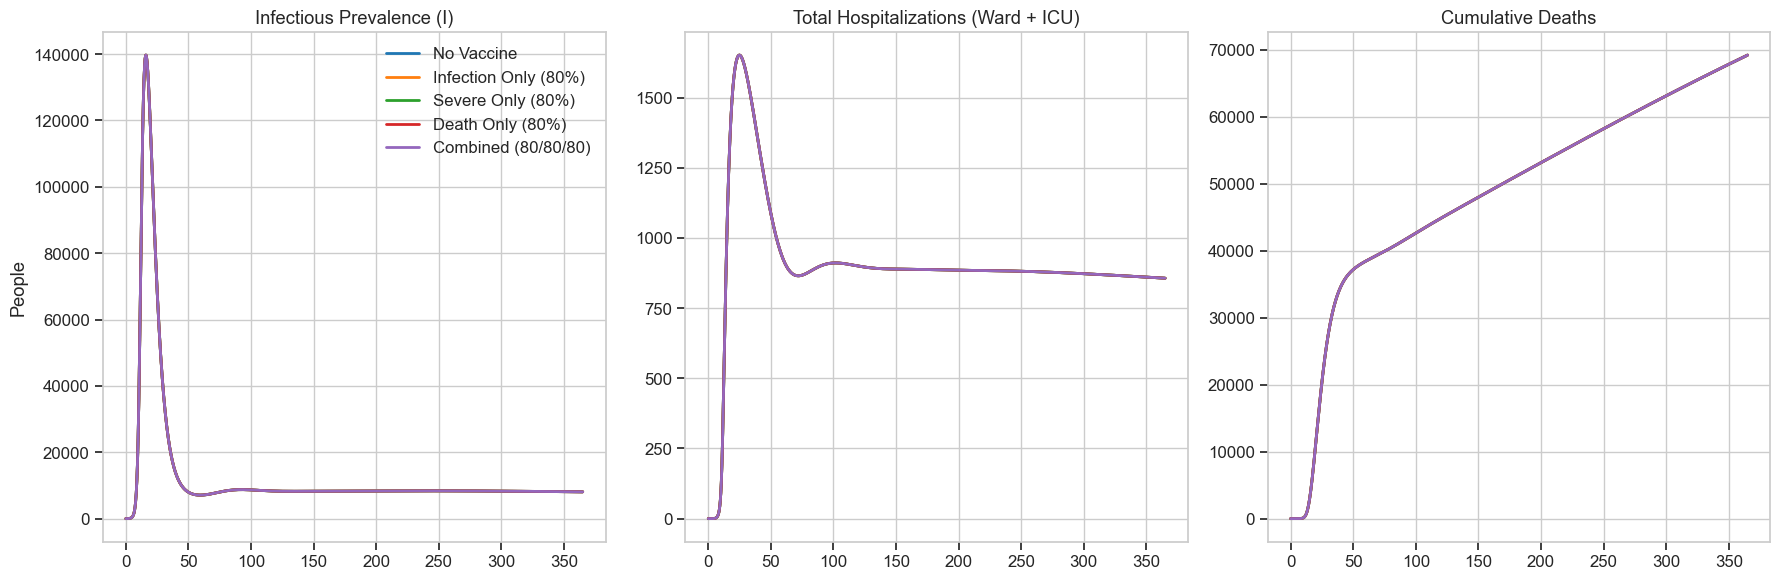

In [6]:
# Experiment 4: VE Component Decomposition

print("Running Experiment 4: VE Component Decomposition...")

base_params = get_scenario_params('covid_delta')
# Set high coverage to see effects clearly
base_params['vaccine_config']['coverage'] = [0.8, 0.8, 0.8]

# Define variants
variants = {
    'No Vaccine': {
        'vaccine_config': {'VE_infection': 0.0, 'VE_severe': 0.0, 'VE_death': 0.0},
        'vaccine_config': {'coverage': [0.0, 0.0, 0.0]}
    },
    'Infection Only (80%)': {
        'vaccine_config': {'VE_infection': 0.8, 'VE_severe': 0.0, 'VE_death': 0.0},
    },
    'Severe Only (80%)': {
        'vaccine_config': {'VE_infection': 0.0, 'VE_severe': 0.8, 'VE_death': 0.0}
    },
    'Death Only (80%)': {
        'vaccine_config': {'VE_infection': 0.0, 'VE_severe': 0.0, 'VE_death': 0.8}
    },
    'Combined (80/80/80)': {
        'vaccine_config': {'VE_infection': 0.8, 'VE_severe': 0.8, 'VE_death': 0.8}
    }
}

results_exp4 = {}
for name, overrides in variants.items():
    # Merge overrides into base params
    p = deepcopy(base_params)
    p.update(overrides)
        
    results_exp4[name] = simulate_master_hospital_model(**p)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Infections
for name, res in results_exp4.items():
    # Calculate daily new infections (approximate from cumulative I if needed, or just I prevalence)
    # Here we plot I_total (prevalence)
    axes[0].plot(res['times'], res['I_total'], label=name, linewidth=2)
axes[0].set_title('Infectious Prevalence (I)')
axes[0].set_ylabel('People')
axes[0].legend()

# Plot 2: Hospitalizations
for name, res in results_exp4.items():
    h_ward = np.array(res['H_ward_total']) if isinstance(res['H_ward_total'], list) else res['H_ward_total']
    h_icu = np.array(res['H_icu_total']) if isinstance(res['H_icu_total'], list) else res['H_icu_total']
    axes[1].plot(res['times'], h_ward + h_icu, label=name, linewidth=2)
axes[1].set_title('Total Hospitalizations (Ward + ICU)')

# Plot 3: Deaths
for name, res in results_exp4.items():
    d_total = np.array(res['D_total']) if isinstance(res['D_total'], list) else res['D_total']
    axes[2].plot(res['times'], d_total, label=name, linewidth=2)
axes[2].set_title('Cumulative Deaths')

plt.savefig('../results/ve_decomposition.png')
plt.tight_layout()
plt.show()

Running Experiment 5: Vaccine Profile Comparison...


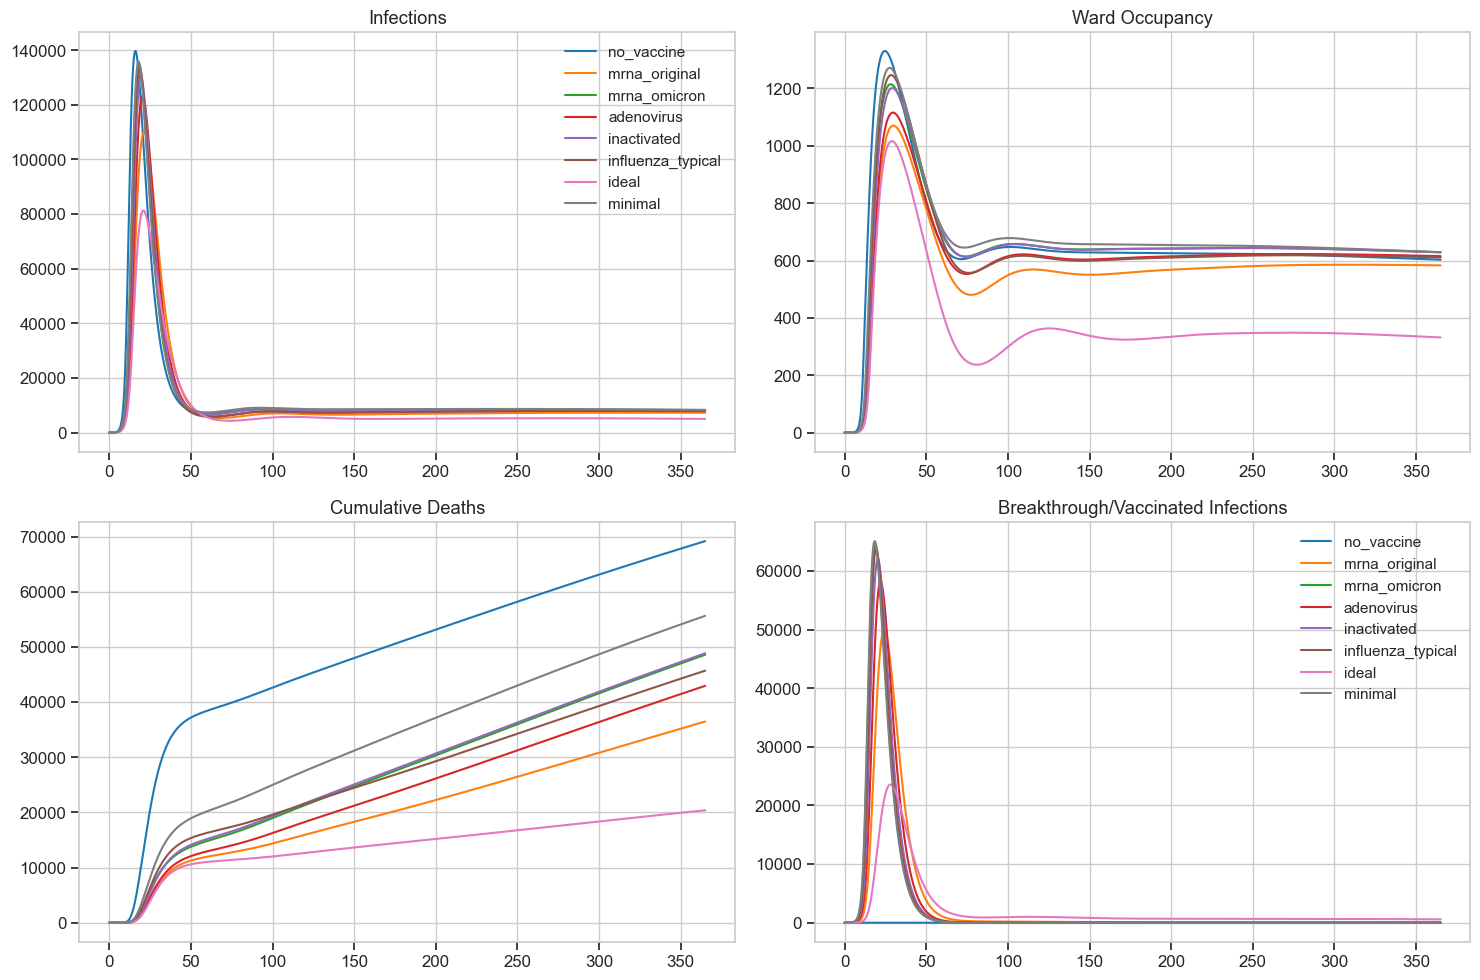

In [7]:
# Experiment 5: Vaccine Profile Comparison

print("Running Experiment 5: Vaccine Profile Comparison...")

# Compare all available profiles
profiles = list_vaccine_profiles()
scenarios_exp5 = compare_vaccine_profiles('covid_delta', profiles)

results_exp5 = {}
for name, params in scenarios_exp5.items():
    results_exp5[name] = simulate_master_hospital_model(**params)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Infections
for name, res in results_exp5.items():
    axes[0,0].plot(res['times'], res['I_total'], label=name)
axes[0,0].set_title('Infections')
axes[0,0].legend(fontsize='small')

# Hospitalizations
for name, res in results_exp5.items():
    axes[0,1].plot(res['times'], res['H_ward_total'], label=name)
axes[0,1].set_title('Ward Occupancy')

# Deaths
for name, res in results_exp5.items():
    axes[1,0].plot(res['times'], res['D_total'], label=name)
axes[1,0].set_title('Cumulative Deaths')

# Breakthroughs (or Vaccinated Infections)
has_breakthrough_data = False
for name, res in results_exp5.items():
    if 'cum_breakthrough' in res:
        # Sum across ages
        breakthroughs = np.sum(res['cum_breakthrough'], axis=0)
        axes[1,1].plot(res['times'], breakthroughs, label=name)
        has_breakthrough_data = True
    elif 'I_vax' in res:
        # Alternative: plot vaccinated infectious prevalence
        i_vax = np.sum(res['I_vax'], axis=0)
        axes[1,1].plot(res['times'], i_vax, label=name)
        has_breakthrough_data = True

if has_breakthrough_data:
    axes[1,1].set_title('Breakthrough/Vaccinated Infections')
    axes[1,1].legend(fontsize='small')
else:
    axes[1,1].text(0.5, 0.5, 'No breakthrough data available', 
                   ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Breakthrough Infections (No Data)')

plt.tight_layout()
plt.savefig('../results/vaccine_profiles_comparison.png')
plt.show()

Running Experiment 6: Waning Dynamics...


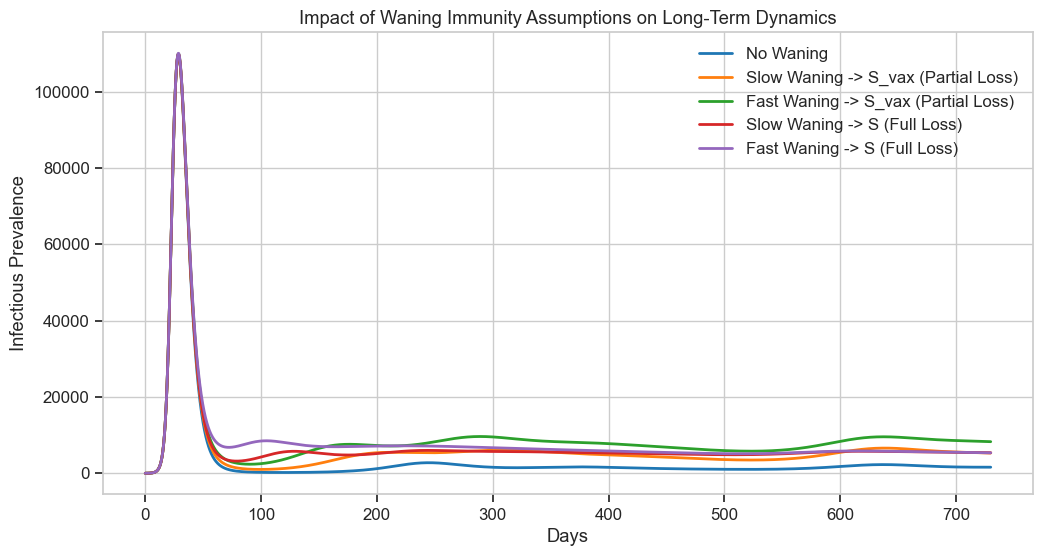

In [8]:
# Experiment 6: Waning Dynamics

print("Running Experiment 6: Waning Dynamics...")

base_params = get_scenario_params('endemic') # Uses 730 days
base_params['vaccine_config']['coverage'] = [0.7, 0.7, 0.9]

# Define waning scenarios
waning_scenarios = {
    'No Waning': {
        'vaccine_waning_config': {'omega_vax': 0.0}
    },
    'Slow Waning -> S_vax (Partial Loss)': {
        'vaccine_waning_config': {'omega_vax': 1/365, 'waning_destination': 'S_vax'}
    },
    'Fast Waning -> S_vax (Partial Loss)': {
        'vaccine_waning_config': {'omega_vax': 1/180, 'waning_destination': 'S_vax'}
    },
    'Slow Waning -> S (Full Loss)': {
        'vaccine_waning_config': {'omega_vax': 1/365, 'waning_destination': 'S'}
    },
    'Fast Waning -> S (Full Loss)': {
        'vaccine_waning_config': {'omega_vax': 1/180, 'waning_destination': 'S'}
    }
}

results_exp6 = {}
for name, overrides in waning_scenarios.items():
    p = deepcopy(base_params)
    p.update(overrides)
    results_exp6[name] = simulate_master_hospital_model(**p)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
for name, res in results_exp6.items():
    ax.plot(res['times'], res['I_total'], label=name, linewidth=2)

ax.set_title('Impact of Waning Immunity Assumptions on Long-Term Dynamics')
ax.set_ylabel('Infectious Prevalence')
ax.set_xlabel('Days')
ax.legend()
plt.savefig('../results/waning_dynamics.png')
plt.show()

# III. Healthcare Capacity Dynamics

These experiments investigate how hospital capacity constraints and the "hardness" of those constraints (Hill coefficients) affect mortality outcomes.

Running Experiment 7: Hill Coefficient Sensitivity...


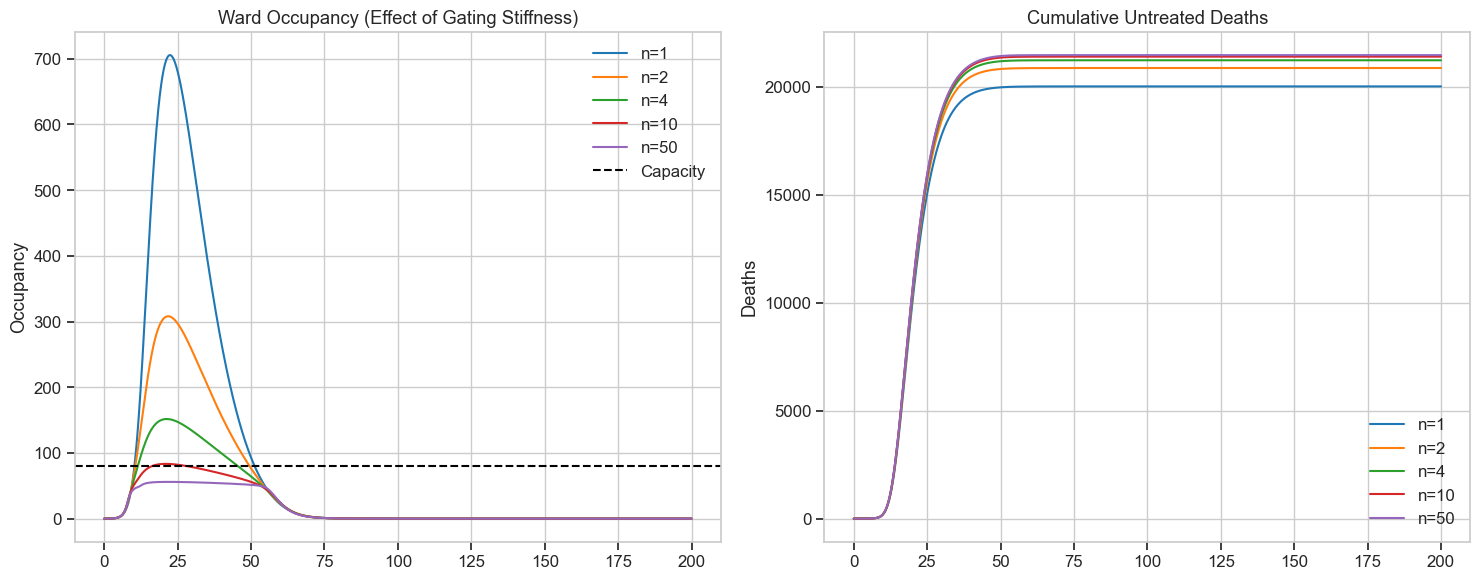

In [9]:
# Experiment 7: Hill Coefficient Sensitivity

print("Running Experiment 7: Hill Coefficient Sensitivity...")

base_params = get_scenario_params('stress_test')
# Ensure we have a scenario where capacity is challenged

hill_values = [1, 2, 4, 10, 50]
results_exp7 = {}

for n in hill_values:
    p = deepcopy(base_params)
    p['capacity_config']['hill_coef_ward'] = n
    p['capacity_config']['hill_coef_icu'] = n
    results_exp7[f'n={n}'] = simulate_master_hospital_model(**p)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Ward Occupancy vs Capacity
capacity = base_params['capacity_config']['ward_capacity']
for name, res in results_exp7.items():
    ax1.plot(res['times'], res['H_ward_total'], label=name)
ax1.axhline(capacity, color='k', linestyle='--', label='Capacity')
ax1.set_title('Ward Occupancy (Effect of Gating Stiffness)')
ax1.set_ylabel('Occupancy')
ax1.legend()

# Plot 2: Untreated Deaths
for name, res in results_exp7.items():
    # Sum untreated deaths
    untreated = np.sum(res['D_untreated'], axis=0)
    ax2.plot(res['times'], untreated, label=name)
ax2.set_title('Cumulative Untreated Deaths')
ax2.set_ylabel('Deaths')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/hill_coef_sensitivity.png')
plt.show()

Running Experiment 8: Optimal Ward:ICU Ratio...


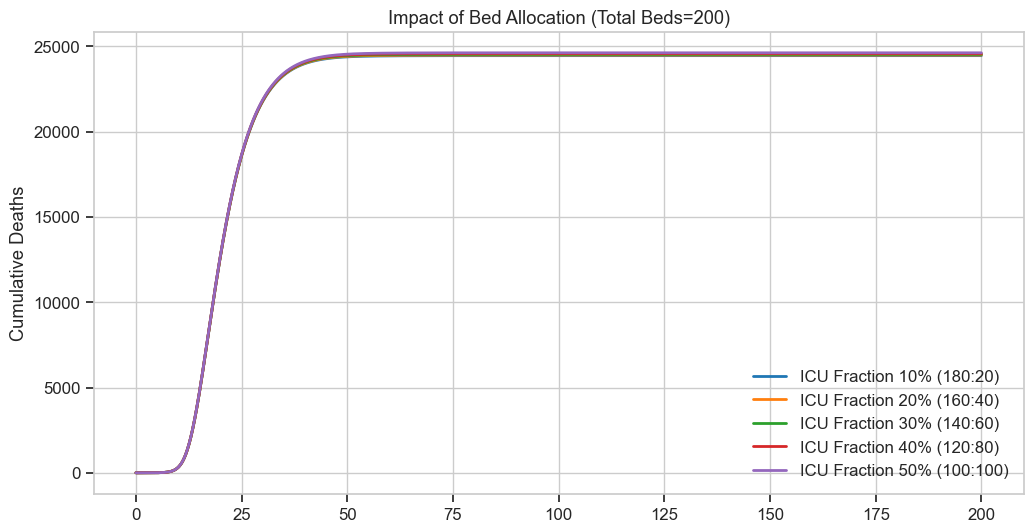

In [10]:
# Experiment 8: Optimal Ward:ICU Ratio

print("Running Experiment 8: Optimal Ward:ICU Ratio...")

base_params = get_scenario_params('stress_test')
total_beds = 200
ratios = [0.1, 0.2, 0.3, 0.4, 0.5] # ICU fraction

results_exp8 = {}
for r in ratios:
    p = deepcopy(base_params)
    icu_beds = int(total_beds * r)
    ward_beds = total_beds - icu_beds
    p['capacity_config']['ward_capacity'] = ward_beds
    p['capacity_config']['icu_capacity'] = icu_beds
    
    results_exp8[f'ICU Fraction {r:.0%} ({ward_beds}:{icu_beds})'] = simulate_master_hospital_model(**p)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
for name, res in results_exp8.items():
    ax.plot(res['times'], res['D_total'], label=name, linewidth=2)

ax.set_title(f'Impact of Bed Allocation (Total Beds={total_beds})')
ax.set_ylabel('Cumulative Deaths')
ax.legend()
plt.savefig('../results/bed_allocation_impact.png')
plt.show()

Running Experiment 9: Healthcare System Comparison...


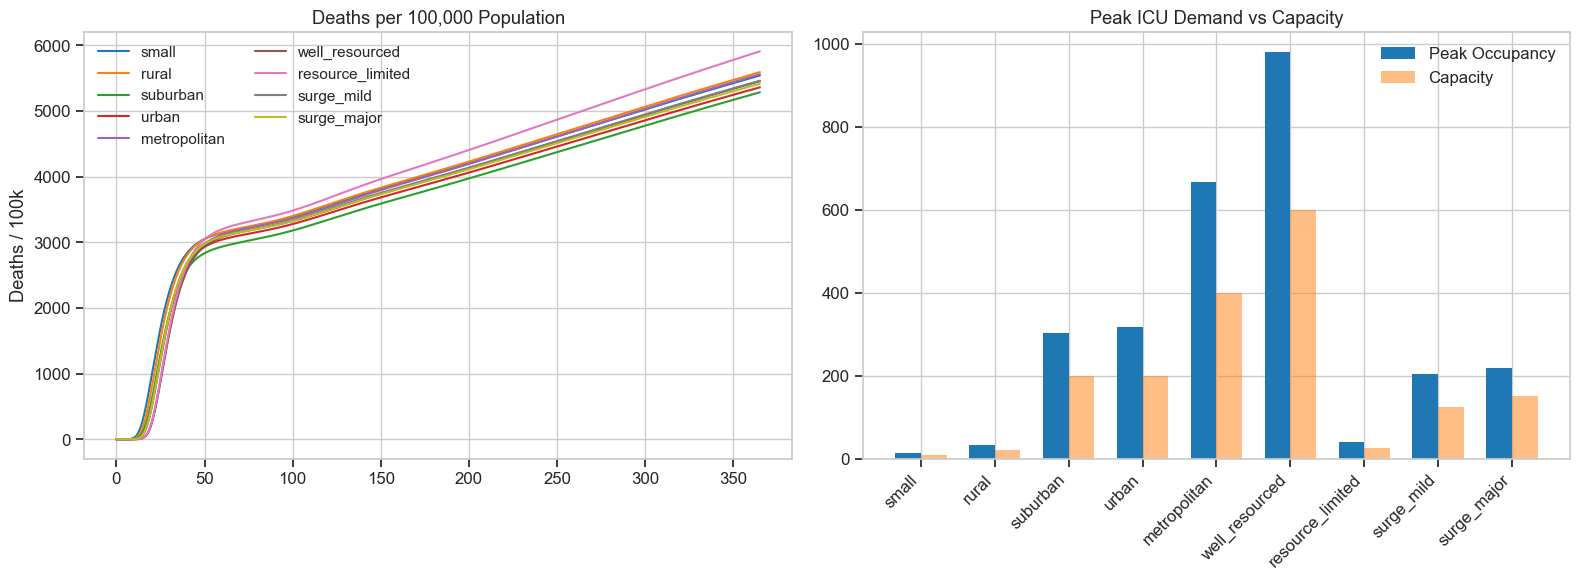

In [11]:
# Experiment 9: Healthcare System Comparison

print("Running Experiment 9: Healthcare System Comparison...")

systems = list(get_healthcare_systems().keys())
scenarios_exp9 = compare_healthcare_systems('covid_delta', systems)

results_exp9 = {}
for name, params in scenarios_exp9.items():
    results_exp9[name] = simulate_master_hospital_model(**params)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Deaths per 100k
for name, res in results_exp9.items():
    # Get population for this system
    pop = sum(scenarios_exp9[name]['age_pops'])
    d_total = np.array(res['D_total']) if isinstance(res['D_total'], list) else res['D_total']
    deaths_per_100k = (d_total / pop) * 100000
    axes[0].plot(res['times'], deaths_per_100k, label=name)
axes[0].set_title('Deaths per 100,000 Population')
axes[0].set_ylabel('Deaths / 100k')
axes[0].legend(fontsize='small', ncol=2)

# Plot 2: Peak ICU Occupancy vs Capacity
names = []
peaks = []
caps = []
for name, res in results_exp9.items():
    names.append(name)
    peaks.append(np.max(res['H_icu_total']))
    caps.append(scenarios_exp9[name]['capacity_config']['icu_capacity'])

x = np.arange(len(names))
width = 0.35
axes[1].bar(x - width/2, peaks, width, label='Peak Occupancy')
axes[1].bar(x + width/2, caps, width, label='Capacity', alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=45, ha='right')
axes[1].set_title('Peak ICU Demand vs Capacity')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/healthcare_system_comparison.png')
plt.show()

# IV. Time-Varying Dynamics

These experiments explore dynamic behaviors driven by seasonality, policy interventions, and adaptive feedback loops.

Running Experiment 10: Seasonality x Waning...


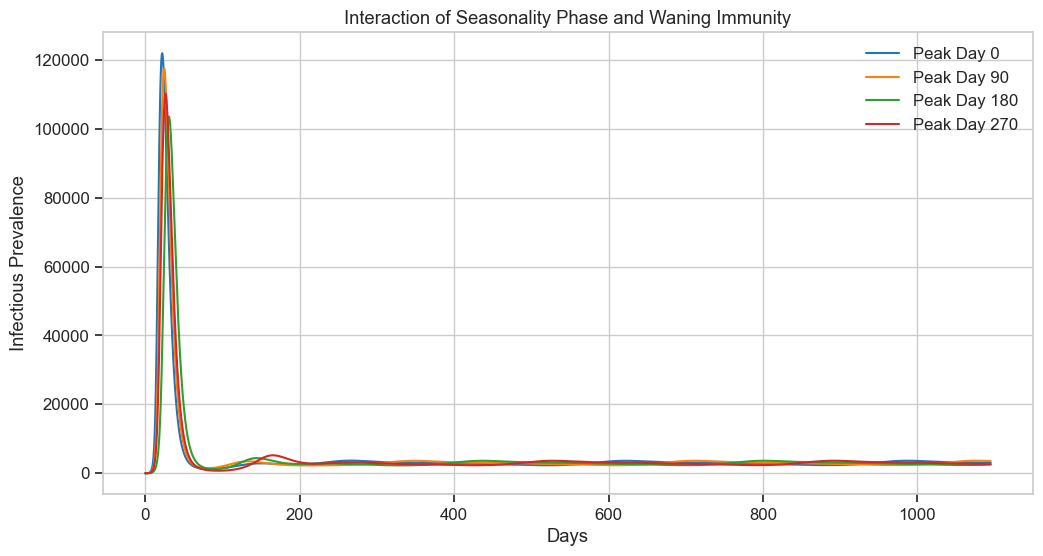

In [12]:
# Experiment 10: Seasonality x Waning Interaction

print("Running Experiment 10: Seasonality x Waning...")

base_params = get_scenario_params('endemic')
base_params['sim_config']['Tmax'] = 365 * 3 # 3 years

# Define scenarios with different seasonal peaks
peaks = [0, 90, 180, 270] # Days offset
results_exp10 = {}

for peak in peaks:
    p = deepcopy(base_params)
    p['seasonal_config'] = {
        'amplitude': 0.3,
        'period': 365,
        'peak_day': peak
    }
    results_exp10[f'Peak Day {peak}'] = simulate_master_hospital_model(**p)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
for name, res in results_exp10.items():
    ax.plot(res['times'], res['I_total'], label=name)

ax.set_title('Interaction of Seasonality Phase and Waning Immunity')
ax.set_ylabel('Infectious Prevalence')
ax.set_xlabel('Days')
ax.legend()
plt.savefig('../results/seasonality_waning_interaction.png')
plt.show()

Running Experiment 11: Intervention Strategy Comparison...


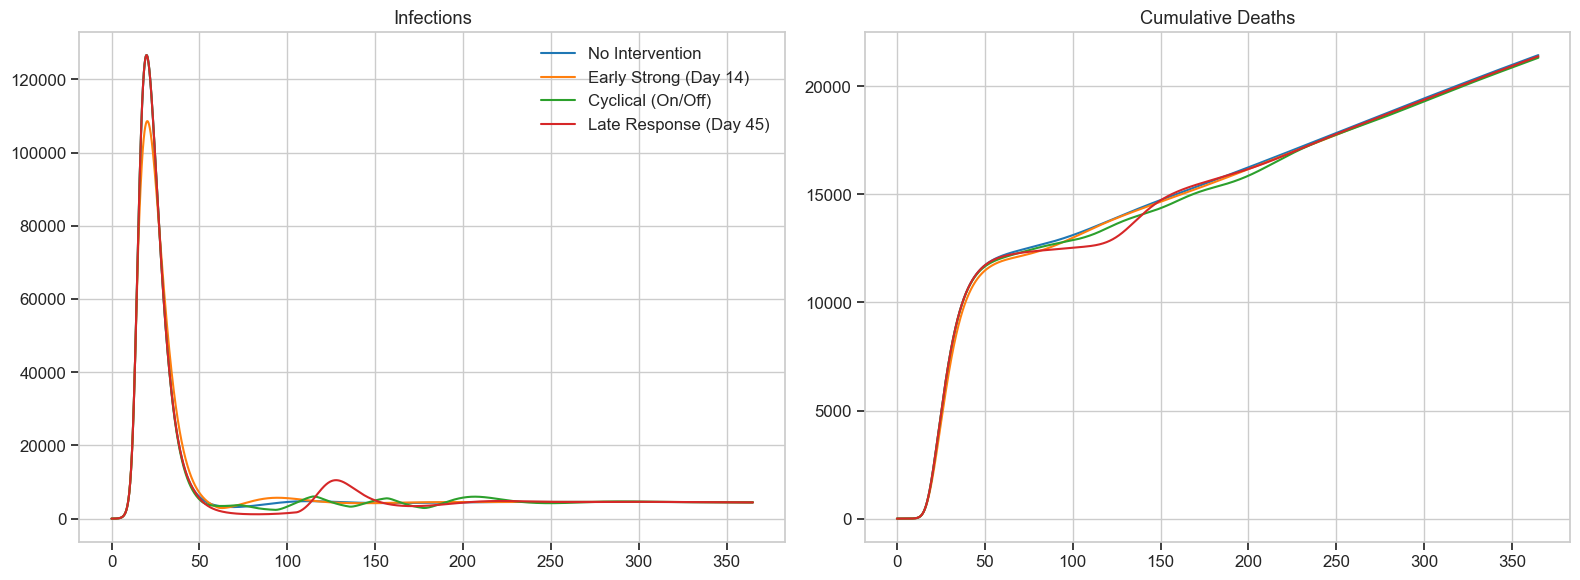

In [13]:
from config_helpers import create_intervention_comparison

print("Running Experiment 11: Intervention Strategy Comparison...")

# Define a set of interventions to compare
interventions_map = {
    'No Intervention': [],
    'Early Strong (Day 14)': INTERVENTION_EARLY_STRONG,
    'Cyclical (On/Off)': INTERVENTION_CYCLICAL,
    'Late Response (Day 45)': [{'start_day': 45, 'end_day': 105, 'transmission_reduction': 0.6}]
}

# Use the helper function - it handles the config structure for you!
scenarios_exp11 = create_intervention_comparison('covid_delta', interventions_map)

results_exp11 = {}
for name, params in scenarios_exp11.items():
    results_exp11[name] = simulate_master_hospital_model(**params)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Infections
for name, res in results_exp11.items():
    axes[0].plot(res['times'], res['I_total'], label=name)
axes[0].set_title('Infections')
axes[0].legend()

# Deaths
for name, res in results_exp11.items():
    axes[1].plot(res['times'], res['D_total'], label=name)
axes[1].set_title('Cumulative Deaths')

plt.tight_layout()
plt.savefig('../results/intervention_comparison.png')
plt.show()

Running Experiment 12: Adaptive Policy...


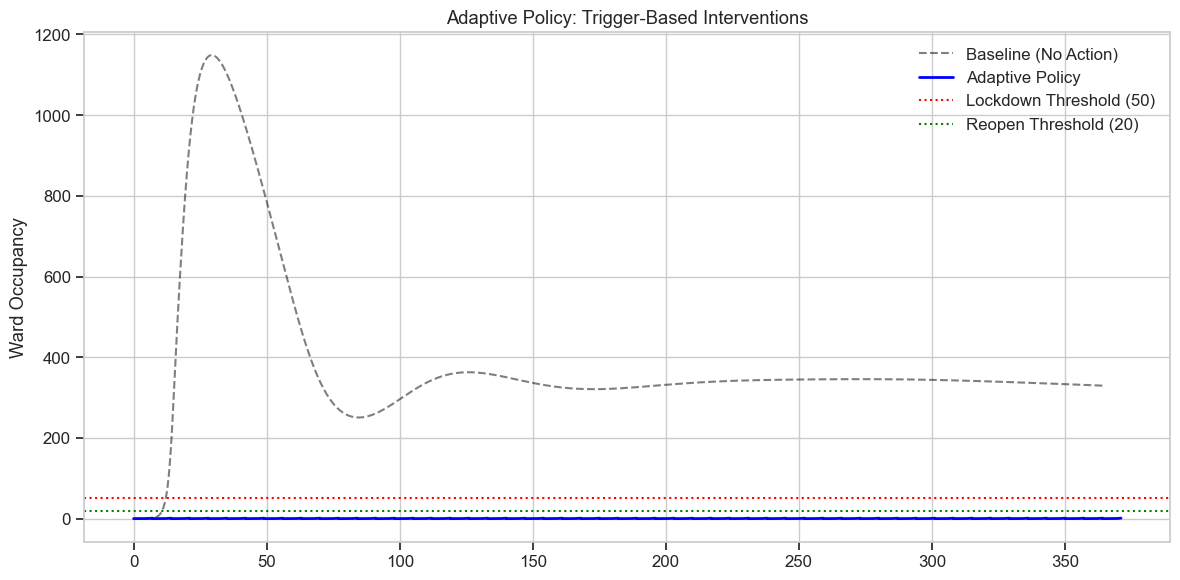

In [14]:
# Experiment 12: Adaptive Policy (Trigger-Based)

print("Running Experiment 12: Adaptive Policy...")

def run_adaptive_simulation(threshold_on=50, threshold_off=20, reduction=0.5):
    # Initial setup
    params = get_scenario_params('covid_delta')
    params['sim_config']['Tmax'] = 365
    
    # State tracking
    final_time = params['sim_config']['Tmax']
    
    # Let's use a simpler approach: 7-day review periods
    review_period = 7
    
    # Initialize accumulators
    full_history = {} # To store concatenated results
    
    # Initial params
    current_params = deepcopy(params)
    current_params['sim_config']['Tmax'] = review_period
    current_params['intervention_config'] = [] # Start open
    
    # Helper to extract state dict from results
    def get_final_state(res):
        state = {}
        for key in res:
            if isinstance(res[key], list) and len(res[key]) > 0:
                # It's a compartment list of arrays
                # Get the last value of each array
                # Check if elements are arrays or scalars
                if isinstance(res[key][0], np.ndarray):
                    state[key] = [arr[-1] for arr in res[key]]
                else:
                    # Already scalar values
                    state[key] = res[key]
        return state

    total_days = 0
    is_locked_down = False
    lockdown_history = []
    
    while total_days < final_time:
        # Run for review_period
        current_params['sim_config']['Tmax'] = review_period
        
        # Apply current policy
        if is_locked_down:
            current_params['intervention_config'] = [{'start_day': 0, 'end_day': review_period + 1, 'transmission_reduction': reduction}]
        else:
            current_params['intervention_config'] = []
            
        res = simulate_master_hospital_model(**current_params)
        
        # Append results
        if total_days == 0:
            # First run - ensure everything is in proper format
            for key in res:
                # Convert aggregate lists to arrays
                if key in ['H_ward_total', 'H_icu_total', 'D_total', 'I_total', 'times']:
                    full_history[key] = np.array(res[key]) if isinstance(res[key], list) else res[key].copy() if isinstance(res[key], np.ndarray) else res[key]
                elif isinstance(res[key], list):
                    full_history[key] = deepcopy(res[key])
                elif isinstance(res[key], np.ndarray):
                    full_history[key] = res[key].copy()
                else:
                    full_history[key] = res[key]
        else:
            # Append (skip first element to avoid duplicate time points)
            for key in res:
                if key == 'times':
                    # Convert times to numpy array if it's a list
                    times_arr = np.array(res['times']) if isinstance(res['times'], list) else res['times']
                    new_times = times_arr[1:] + total_days
                    full_history['times'] = np.concatenate([full_history['times'], new_times])
                elif key in ['H_ward_total', 'H_icu_total', 'D_total', 'I_total']:
                    # These are aggregate arrays - ensure they're treated as arrays
                    arr = np.array(res[key]) if isinstance(res[key], list) else res[key]
                    full_history[key] = np.concatenate([full_history[key], arr[1:]])
                elif isinstance(res[key], list) and len(res[key]) > 0 and isinstance(res[key][0], np.ndarray):
                    # List of arrays (compartments)
                    for i in range(len(res[key])):
                        # Check if element is an array or scalar
                        if isinstance(res[key][i], np.ndarray) and res[key][i].ndim > 0:
                            full_history[key][i] = np.concatenate([full_history[key][i], res[key][i][1:]])
                        # else: scalar, skip (shouldn't happen in normal flow)
                elif isinstance(res[key], np.ndarray):
                    # Other 1D arrays
                    full_history[key] = np.concatenate([full_history[key], res[key][1:]])
                elif isinstance(res[key], (int, float, np.number)):
                    # Scalar values - shouldn't be concatenated
                    pass
        
        # Update state for next iteration
        final_state = get_final_state(res)
        current_params['initial_conditions'] = final_state
        
        # Check trigger
        # Get last H_ward_total
        current_h = res['H_ward_total'][-1]
        
        if is_locked_down:
            if current_h < threshold_off:
                is_locked_down = False
        else:
            if current_h > threshold_on:
                is_locked_down = True
        
        lockdown_history.append((total_days, is_locked_down))
        
        total_days += review_period
        
    return full_history, lockdown_history

# Run adaptive
results_adaptive, history = run_adaptive_simulation()

# Run baseline for comparison
params_base = get_scenario_params('covid_delta')
params_base['sim_config']['Tmax'] = 365
results_base = simulate_master_hospital_model(**params_base)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(results_base['times'], results_base['H_ward_total'], 'k--', alpha=0.5, label='Baseline (No Action)')
ax.plot(results_adaptive['times'], results_adaptive['H_ward_total'], 'b-', linewidth=2, label='Adaptive Policy')

# Plot lockdown periods
# history is list of (day, is_locked)
for i in range(len(history)):
    day, locked = history[i]
    if locked:
        ax.axvspan(day, day+7, color='r', alpha=0.1)

ax.axhline(50, color='r', linestyle=':', label='Lockdown Threshold (50)')
ax.axhline(20, color='g', linestyle=':', label='Reopen Threshold (20)')

ax.set_title('Adaptive Policy: Trigger-Based Interventions')
ax.set_ylabel('Ward Occupancy')
ax.legend()

plt.tight_layout()
plt.savefig('../results/adaptive_policy.png')
plt.show()

# V. Demographics & Long-Term Dynamics

These experiments explore multi-year simulations where births, deaths, and aging (implicitly via replacement) become relevant.

Running Experiment 13: Demographic Dynamics...


/Users/JasonHunter/Desktop/hospital-model/master_hospital_model.py:549: UserWarning: Long simulation (1825 days) with demographic imbalance detected. Expected annual births: 4380, expected annual background deaths: 12848. Net population change: -8468 (2.1%/year). Consider adjusting birth_rate or mu_background for population stability.
  warnings.warn(


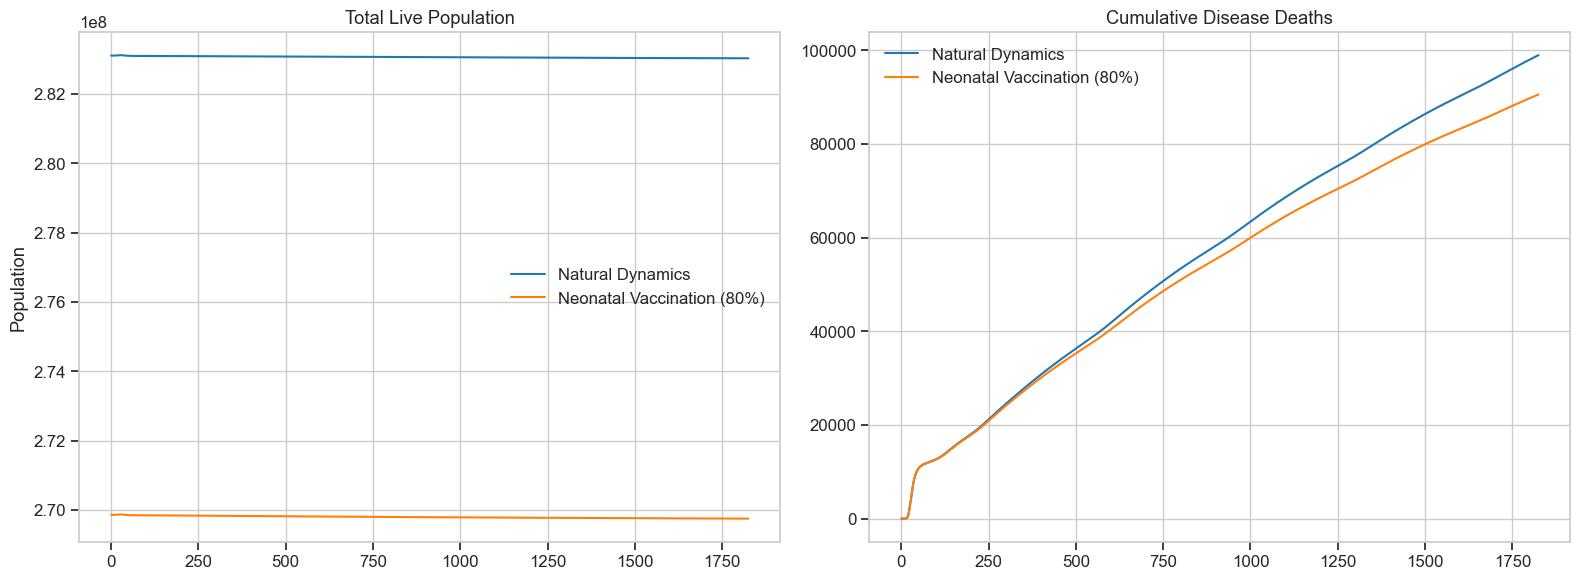

In [15]:
# Experiment 13: Demographic Dynamics & Neonatal Vaccination

print("Running Experiment 13: Demographic Dynamics...")

base_params = get_scenario_params('population_dynamics')
base_params['sim_config']['Tmax'] = 365 * 5 # 5 years

# Compare:
# 1. Natural Dynamics (No Vax)
# 2. Neonatal Vaccination (80% of births -> S_vax)

scenarios_exp13 = {
    'Natural Dynamics': deepcopy(base_params),
    'Neonatal Vaccination (80%)': deepcopy(base_params)
}

# Configure Neonatal Vax - need to ensure demographic_params exists
if 'demographic_params' in scenarios_exp13['Neonatal Vaccination (80%)']:
    scenarios_exp13['Neonatal Vaccination (80%)']['demographic_config']['neonatal_vaccination_rate'] = 0.8
else:
    scenarios_exp13['Neonatal Vaccination (80%)']['demographic_config'] = {
        'birth_rate': 0.00003,
        'mu_background': [0.00001, 0.00005, 0.0003],
        'neonatal_vaccination_rate': 0.8
    }
# Ensure we have a vaccine profile set
scenarios_exp13['Neonatal Vaccination (80%)']['vaccine_config']['vaccine_profile'] = 'vaccine_profile_1'

results_exp13 = {}
for name, params in scenarios_exp13.items():
    results_exp13[name] = simulate_master_hospital_model(**params)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Population (Live)
for name, res in results_exp13.items():
    # Calculate live population
    live_pop = np.zeros_like(res['times'])
    for key in res:
        if key.startswith(('S', 'E', 'I', 'X', 'H', 'R')) and not key.startswith('D'):
             if isinstance(res[key], list):
                 live_pop += np.sum(res[key], axis=0)
    axes[0].plot(res['times'], live_pop, label=name)
axes[0].set_title('Total Live Population')
axes[0].set_ylabel('Population')
axes[0].legend()

# Plot 2: Cumulative Deaths
for name, res in results_exp13.items():
    axes[1].plot(res['times'], res['D_total'], label=name)
axes[1].set_title('Cumulative Disease Deaths')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/demographic_dynamics.png')
plt.show()

Running Experiment 14: Endemic Equilibrium...


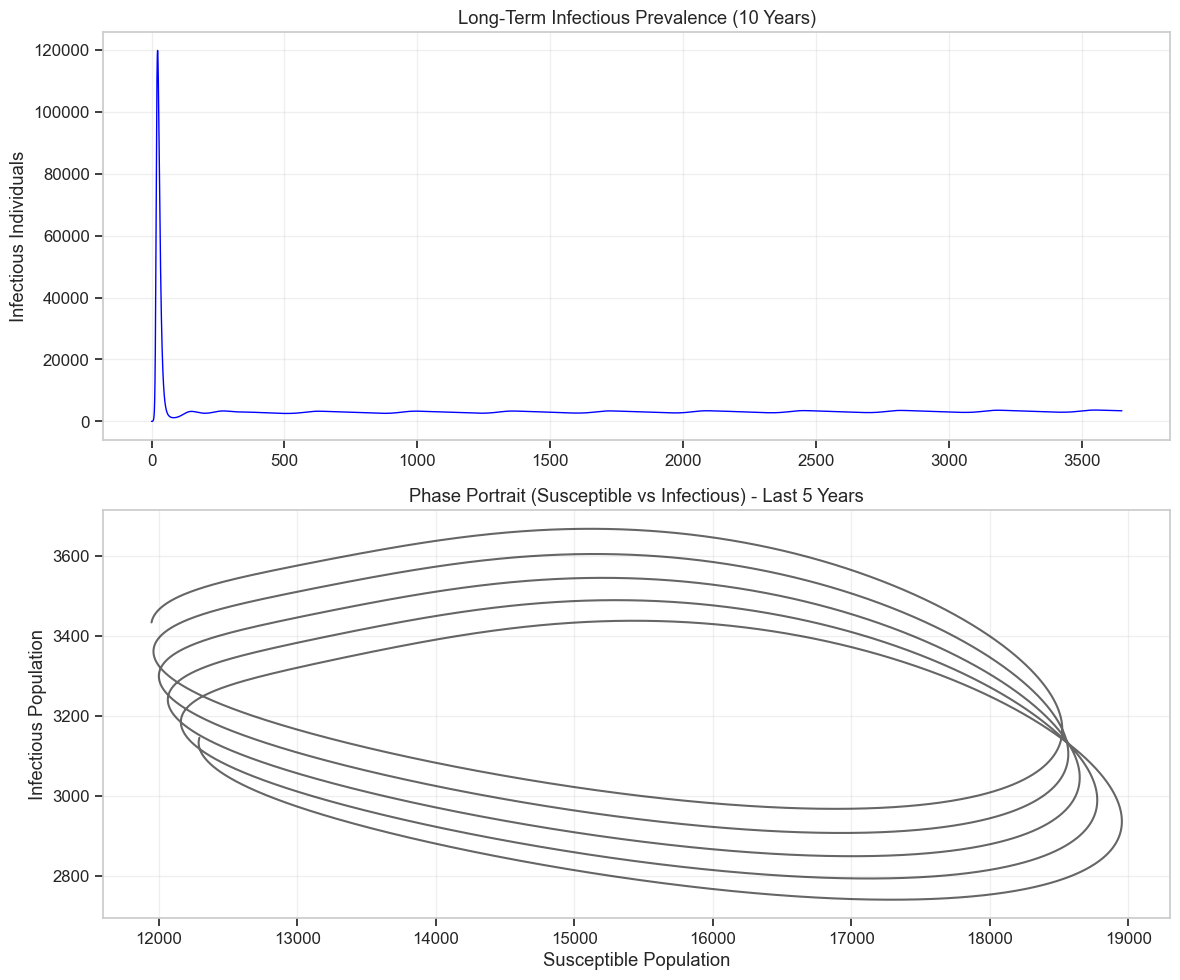

In [16]:
# Experiment 14: Endemic Equilibrium

print("Running Experiment 14: Endemic Equilibrium...")

params = get_scenario_params('endemic')
params['sim_config']['Tmax'] = 365 * 10 # 10 years
params['seasonal_config'] = {'amplitude': 0.2, 'period': 365, 'peak_day': 0}

res = simulate_master_hospital_model(**params)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Long-term Prevalence
ax1.plot(res['times'], res['I_total'], 'b-', linewidth=1)
ax1.set_title('Long-Term Infectious Prevalence (10 Years)')
ax1.set_ylabel('Infectious Individuals')
ax1.grid(True, alpha=0.3)

# Plot 2: Phase Portrait (I vs S)
# Sum S across ages
S_total = np.sum(res['S'], axis=0)
if 'S_vax' in res:
    S_total += np.sum(res['S_vax'], axis=0)

# Use last 5 years to show limit cycle
start_idx = len(res['times']) // 2
ax2.plot(S_total[start_idx:], res['I_total'][start_idx:], 'k-', alpha=0.6)
ax2.set_title('Phase Portrait (Susceptible vs Infectious) - Last 5 Years')
ax2.set_xlabel('Susceptible Population')
ax2.set_ylabel('Infectious Population')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/endemic_equilibrium.png')
plt.show()

# VI. Sensitivity & Synthesis

This section synthesizes multiple parameters to explore interaction effects.

Running Experiment 15: Multi-Parameter Heatmaps...


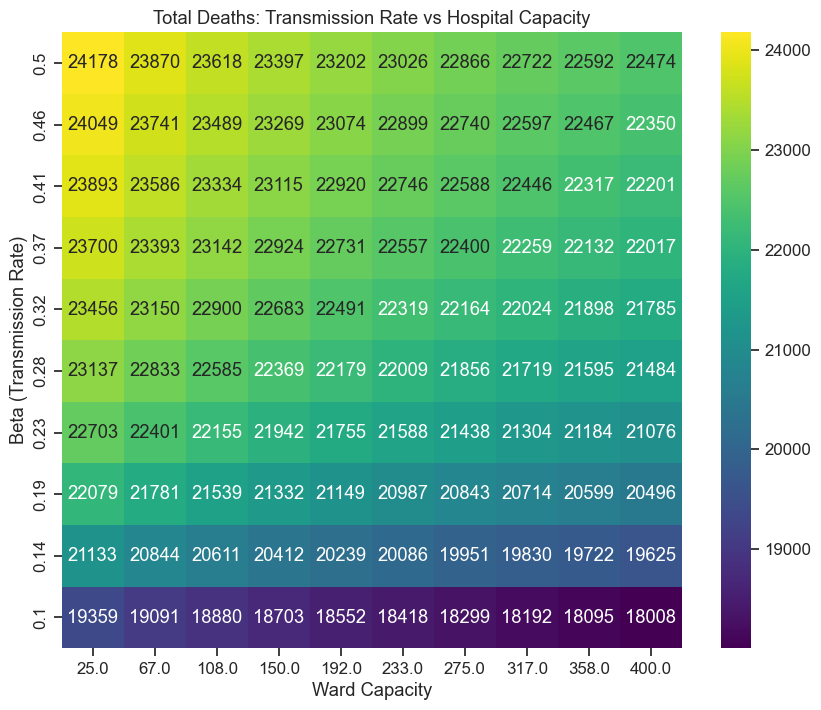

In [17]:
# Experiment 15: Multi-Parameter Heatmaps (Beta vs Capacity)

print("Running Experiment 15: Multi-Parameter Heatmaps...")

base_params = get_scenario_params('covid_delta')

# Define ranges
betas = np.linspace(0.1, 0.5, 10)
capacities = np.linspace(25, 400, 10)

# Grid search
results_grid = np.zeros((len(betas), len(capacities)))

for i, beta in enumerate(betas):
    for j, cap in enumerate(capacities):
        p = deepcopy(base_params)
        p['beta_base'] = beta
        p['capacity_config']['ward_capacity'] = cap
        p['capacity_config']['icu_capacity'] = cap * 0.25 # Maintain ratio
        
        res = simulate_master_hospital_model(**p)
        results_grid[i, j] = res['D_total'][-1]

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(results_grid, xticklabels=np.round(capacities, 0), yticklabels=np.round(betas, 2),
            cmap='viridis', annot=True, fmt='.0f', ax=ax)

ax.set_title('Total Deaths: Transmission Rate vs Hospital Capacity')
ax.set_xlabel('Ward Capacity')
ax.set_ylabel('Beta (Transmission Rate)')
ax.invert_yaxis() # Standard plot orientation
plt.savefig('../results/heatmap_beta_vs_capacity.png')
plt.show()

# Appendix A: Numerical Methods Comparison

This section compares different ODE solvers to ensure numerical stability, especially for stiff systems (e.g., with fast rates or hard capacity limits).

Running Solver Comparison...


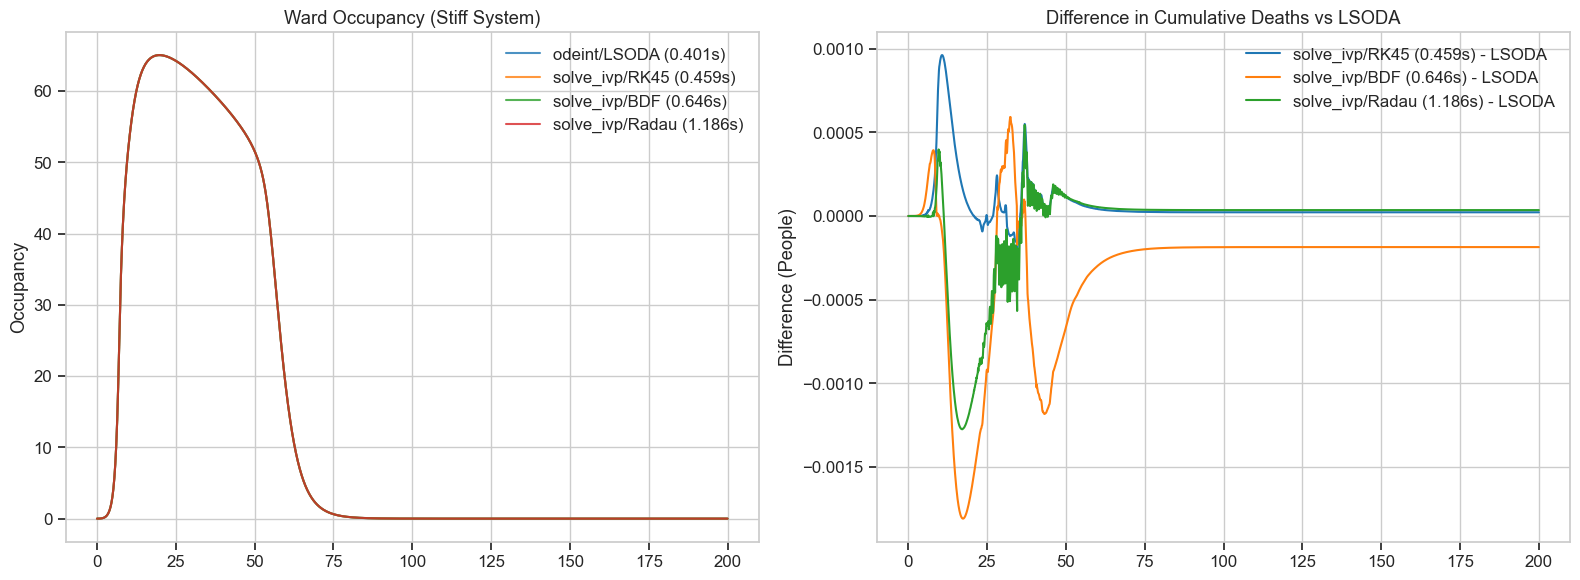

In [18]:
# Appendix A: Solver Comparison

print("Running Solver Comparison...")

base_params = get_scenario_params('stress_test')
# Use a stiff scenario (high transmission, sharp capacity limits)
base_params['capacity_config']['hill_coef_ward'] = 20 # Very sharp cutoff -> stiff
base_params['beta_base'] = 0.5

solvers = [
    ('odeint', 'LSODA'),
    ('solve_ivp', 'RK45'),
    ('solve_ivp', 'BDF'),
    ('solve_ivp', 'Radau')
]

results_solver = {}
import time

for func, method in solvers:
    p = deepcopy(base_params)
    p['solver'] = func
    p['solver_method'] = method
    
    start = time.time()
    try:
        res = simulate_master_hospital_model(**p)
        duration = time.time() - start
        results_solver[f'{func}/{method} ({duration:.3f}s)'] = res
    except Exception as e:
        print(f"Solver {func}/{method} failed: {e}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Ward Occupancy (Zoom in on peak)
for name, res in results_solver.items():
    ax1.plot(res['times'], res['H_ward_total'], label=name, alpha=0.8)
ax1.set_title('Ward Occupancy (Stiff System)')
ax1.set_ylabel('Occupancy')
ax1.legend()

# Plot 2: Difference from LSODA (Reference)
ref_key = [k for k in results_solver.keys() if 'LSODA' in k][0]
ref_res = results_solver[ref_key]

for name, res in results_solver.items():
    if name == ref_key:
        continue
    # Handle D_total which can be array or list
    d_total = np.array(res['D_total']) if isinstance(res['D_total'], list) else res['D_total']
    d_total_ref = np.array(ref_res['D_total']) if isinstance(ref_res['D_total'], list) else ref_res['D_total']
    
    diff = d_total - d_total_ref
    ax2.plot(res['times'], diff, label=f'{name} - LSODA')

ax2.set_title('Difference in Cumulative Deaths vs LSODA')
ax2.set_ylabel('Difference (People)')
ax2.legend()

plt.tight_layout()
plt.savefig('../results/solver_comparison.png')
plt.show()